# Model Training

## Packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn import metrics
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
import shap
from sklearn import preprocessing
import plotly.express as px
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import os
import sys

sys.path.append(os.path.abspath(".."))
from Helpers.utils import get_supabase, get_supabase_df

## Loading Dataframe and Splitting Training and Test

In [3]:
# Get DataFrame
df = get_supabase_df("master_df")
print(df.dtypes)
df.head(50)

meeting_key              int64
driver_number            int64
quali_best_lap         float64
quali_median_ts        float64
race_start_position    float64
Practice1_best_lap     float64
Practice2_best_lap     float64
Practice3_best_lap     float64
is_sprint_weekend         bool
country_key              int64
circuit_key              int64
year                     int64
month                    int64
day                      int64
pressure               float64
rainfall_status           bool
track_temperature      float64
wind_speed             float64
wind_direction         float64
air_temperature        float64
end_position             int64
dtype: object


,meeting_key,driver_number,quali_best_lap,quali_median_ts,race_start_position,Practice1_best_lap,Practice2_best_lap,Practice3_best_lap,is_sprint_weekend,country_key,...,year,month,day,pressure,rainfall_status,track_temperature,wind_speed,wind_direction,air_temperature,end_position
0,1241,10,78.166,300.0,20.0,79.976,78.888,77.499,False,14,...,2024,7,21,981.676774,False,44.916129,1.249677,221.187097,28.823871,0
1,1246,20,90.653,297.0,14.0,93.377,91.793,91.265,False,157,...,2024,9,22,1008.024375,False,36.445625,0.955000,192.493750,30.786250,19
2,1244,44,79.513,218.0,6.0,82.214,80.738,80.117,False,13,...,2024,9,1,993.228571,False,49.311278,1.518797,200.624060,33.101504,5
3,1262,23,72.641,267.5,11.0,NaN,73.839,74.289,False,1,...,2025,6,1,1002.771613,False,48.543226,1.632903,147.109677,29.120000,0
4,1236,11,72.060,269.0,16.0,73.229,72.099,71.923,False,114,...,2024,5,26,1018.744724,False,46.327638,0.978392,160.527638,21.595477,0
5,1258,81,87.304,303.0,2.0,89.341,88.430,87.513,False,153,...,2025,4,20,1006.766197,False,37.819718,1.026056,215.732394,29.483803,1
6,1258,1,87.294,300.0,1.0,89.818,88.547,88.334,False,153,...,2025,4,20,1006.766197,False,37.819718,1.026056,215.732394,29.483803,2
7,1258,16,87.670,246.5,4.0,89.309,88.749,88.372,False,153,...,2025,4,20,1006.766197,False,37.819718,1.026056,215.732394,29.483803,3
8,1258,4,87.481,219.0,10.0,89.246,88.267,87.489,False,153,...,2025,4,20,1006.766197,False,37.819718,1.026056,215.732394,29.483803,4
9,1258,63,87.407,293.0,3.0,89.618,88.973,88.116,False,153,...,2025,4,20,1006.766197,False,37.819718,1.026056,215.732394,29.483803,5


In [4]:
# models can't handle NaN so check which rows have nulls
df[["Practice1_best_lap","Practice2_best_lap","Practice3_best_lap"]].isna().value_counts()

# handle NaN
# Columns you want to impute (numeric performance metrics, etc.)
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Step 1: Impute within (circuit_key, meeting_key, driver_number)
df[numeric_cols] = df.groupby(['circuit_key', 'meeting_key', 'driver_number'])[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

# Step 2: Fallback — within (circuit_key, driver_number)
df[numeric_cols] = df.groupby(['circuit_key', 'driver_number'])[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

# Step 3: Fallback — within circuit_key
df[numeric_cols] = df.groupby('circuit_key')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

# Step 4: Final global fallback (in case any remain)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("✅ Imputation complete.")
print(df.isna().sum().sum(), "NaN values remain.")
print(df.shape)
df

✅ Imputation complete.
0 NaN values remain.
(651, 21)


,meeting_key,driver_number,quali_best_lap,quali_median_ts,race_start_position,Practice1_best_lap,Practice2_best_lap,Practice3_best_lap,is_sprint_weekend,country_key,...,year,month,day,pressure,rainfall_status,track_temperature,wind_speed,wind_direction,air_temperature,end_position
0,1241,10,78.166,300.0,20.0,79.976,78.888,77.499,False,14,...,2024,7,21,981.676774,False,44.916129,1.249677,221.187097,28.823871,0
1,1246,20,90.653,297.0,14.0,93.377,91.793,91.265,False,157,...,2024,9,22,1008.024375,False,36.445625,0.955000,192.493750,30.786250,19
2,1244,44,79.513,218.0,6.0,82.214,80.738,80.117,False,13,...,2024,9,1,993.228571,False,49.311278,1.518797,200.624060,33.101504,5
3,1262,23,72.641,267.5,11.0,74.746,73.839,74.289,False,1,...,2025,6,1,1002.771613,False,48.543226,1.632903,147.109677,29.120000,0
4,1236,11,72.060,269.0,16.0,73.229,72.099,71.923,False,114,...,2024,5,26,1018.744724,False,46.327638,0.978392,160.527638,21.595477,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,1270,12,89.537,302.0,4.0,92.399,92.719,90.237,False,157,...,2025,10,5,1010.782500,True,33.850625,1.110000,149.706250,29.074375,5
647,1270,16,89.784,301.5,7.0,91.266,91.466,90.651,False,157,...,2025,10,5,1010.782500,True,33.850625,1.110000,149.706250,29.074375,6
648,1270,14,89.955,261.5,10.0,91.116,90.877,90.923,False,157,...,2025,10,5,1010.782500,True,33.850625,1.110000,149.706250,29.074375,7
649,1270,44,89.688,269.0,6.0,91.480,91.491,90.559,False,157,...,2025,10,5,1010.782500,True,33.850625,1.110000,149.706250,29.074375,8


In [5]:
# Alter target variable to classification problem for podium
df["podium"] = (df["end_position"] <= 3) & (df["end_position"] > 0)

In [6]:
# Define features and target
X = df.drop(columns=["end_position", "podium"])
y = df["podium"]

# Define groups to avoid leakage
groups = df["meeting_key"]

# Create one group split (80/20)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in splitter.split(X, y, groups):
    train_X, test_X = X.iloc[train_idx], X.iloc[test_idx]
    train_y, test_y = y.iloc[train_idx], y.iloc[test_idx]

# (Optional) Verify group separation
print(f"Train races: {len(train_X['meeting_key'].unique())}, Test races: {len(test_X['meeting_key'].unique())}")

# ✅ Drop meeting_key from the features AFTER splitting
train_X = train_X.drop(columns=["meeting_key"])
test_X = test_X.drop(columns=["meeting_key"])


Train races: 33, Test races: 9


## Loop Through Models and Display Metrics

In [7]:
# models
log_regression = LogisticRegression(max_iter=5000, random_state=42)
decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
gradient_boosting = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_balanced = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
xg_boost = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

models = [log_regression, decision_tree, random_forest, gradient_boosting, gb_balanced, xg_boost]


=== Results using ORIGINAL data ===
LogisticRegression_original:
  Accuracy: 89.820%
  F1 Score: 0.679
  ROC AUC: 0.79
    pred_y  true_y  test_prob
87    True    True   0.746061
88    True    True   0.604371
89    True    True   0.632477
90   False   False   0.213201
91   False   False   0.130902


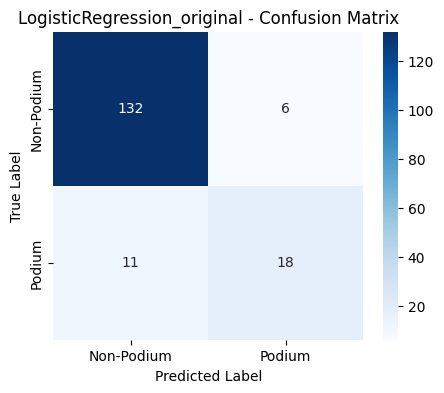

DecisionTreeClassifier_original:
  Accuracy: 91.617%
  F1 Score: 0.767
  ROC AUC: 0.87
    pred_y  true_y  test_prob
87    True    True   0.911111
88    True    True   0.911111
89    True    True   0.911111
90   False   False   0.016892
91   False   False   0.016892


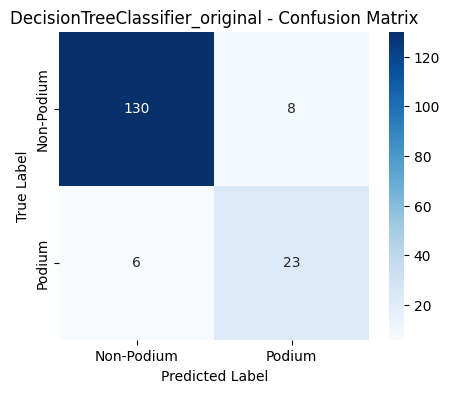

RandomForestClassifier_original:
  Accuracy: 91.617%
  F1 Score: 0.741
  ROC AUC: 0.83
    pred_y  true_y  test_prob
87    True    True       0.70
88    True    True       0.56
89    True    True       0.57
90   False   False       0.08
91   False   False       0.05


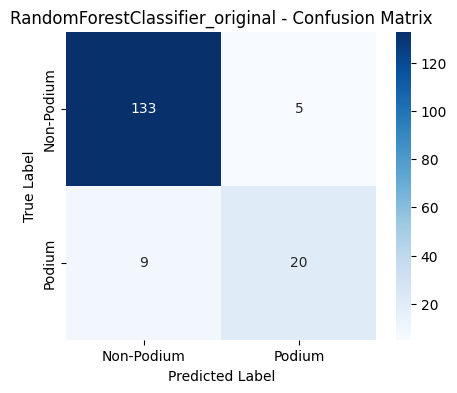

GradientBoostingClassifier_original:
  Accuracy: 92.216%
  F1 Score: 0.780
  ROC AUC: 0.87
    pred_y  true_y  test_prob
87    True    True   0.857235
88    True    True   0.659679
89    True    True   0.726066
90   False   False   0.024891
91   False   False   0.012335


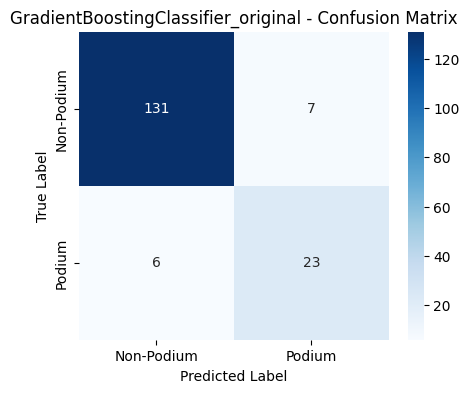

HistGradientBoostingClassifier_original:
  Accuracy: 90.419%
  F1 Score: 0.733
  ROC AUC: 0.85
    pred_y  true_y  test_prob
87    True    True   0.963100
88    True    True   0.964561
89    True    True   0.846345
90   False   False   0.018763
91   False   False   0.045983


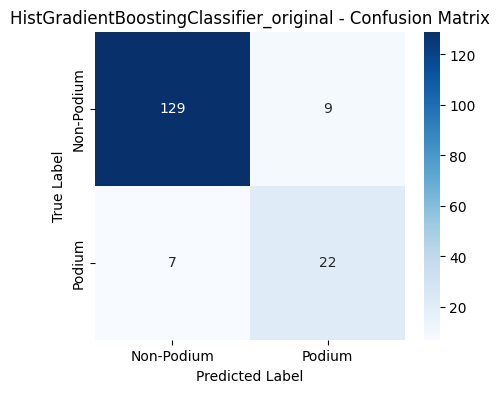

/Users/baole/Documents/F1 Machine Learning Model/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:23:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier_original:
  Accuracy: 92.814%
  F1 Score: 0.806
  ROC AUC: 0.90
    pred_y  true_y  test_prob
87       1    True   0.967390
88       1    True   0.876826
89       1    True   0.838739
90       0   False   0.011187
91       0   False   0.008050


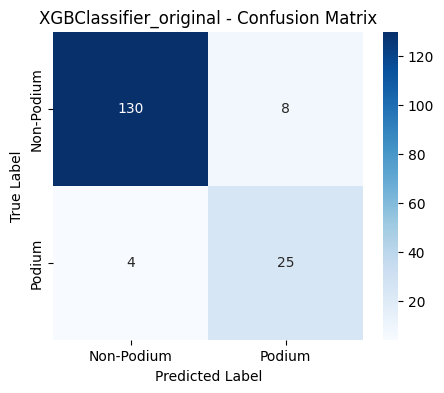


=== Results using SMOTE data ===
LogisticRegression_smote:
  Accuracy: 86.228%
  F1 Score: 0.685
  ROC AUC: 0.86
    pred_y  true_y  test_prob
87    True    True   0.930884
88    True    True   0.823785
89    True    True   0.879717
90   False   False   0.486113
91   False   False   0.272750


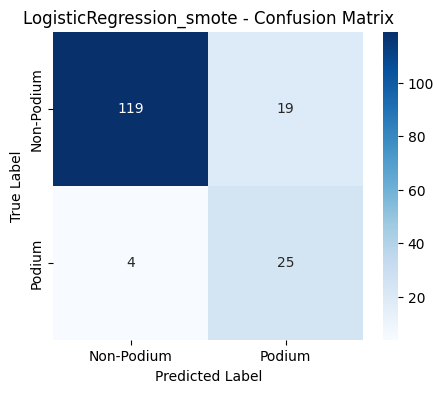

DecisionTreeClassifier_smote:
  Accuracy: 88.623%
  F1 Score: 0.708
  ROC AUC: 0.85
    pred_y  true_y  test_prob
87    True    True   0.946903
88    True    True   0.946903
89    True    True   0.946903
90   False   False   0.125000
91   False   False   0.000000


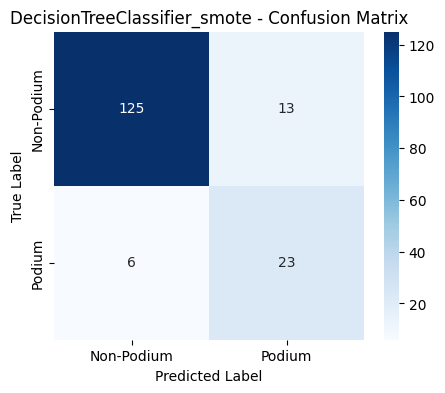

RandomForestClassifier_smote:
  Accuracy: 91.617%
  F1 Score: 0.781
  ROC AUC: 0.89
    pred_y  true_y  test_prob
87    True    True       0.65
88    True    True       0.69
89    True    True       0.63
90   False   False       0.22
91   False   False       0.22


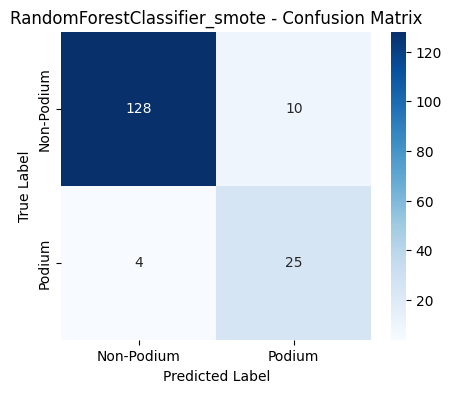

GradientBoostingClassifier_smote:
  Accuracy: 91.617%
  F1 Score: 0.774
  ROC AUC: 0.88
    pred_y  true_y  test_prob
87    True    True   0.961519
88    True    True   0.952354
89    True    True   0.954004
90   False   False   0.045313
91   False   False   0.028268


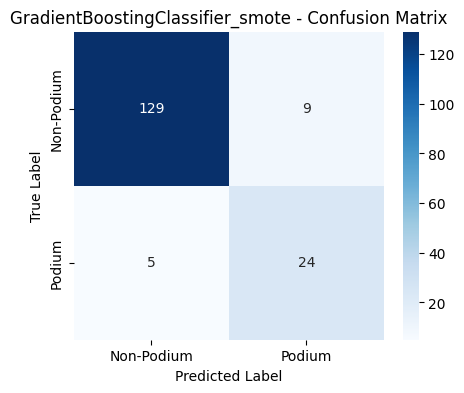

HistGradientBoostingClassifier_smote:
  Accuracy: 91.617%
  F1 Score: 0.767
  ROC AUC: 0.87
    pred_y  true_y  test_prob
87    True    True   0.990544
88    True    True   0.945000
89    True    True   0.744281
90   False   False   0.016286
91   False   False   0.011164


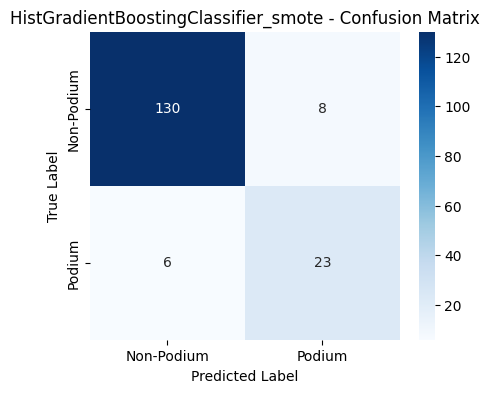

/Users/baole/Documents/F1 Machine Learning Model/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:23:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier_smote:
  Accuracy: 91.018%
  F1 Score: 0.762
  ROC AUC: 0.88
    pred_y  true_y  test_prob
87       1    True   0.981294
88       1    True   0.986199
89       1    True   0.966741
90       0   False   0.016907
91       0   False   0.010105


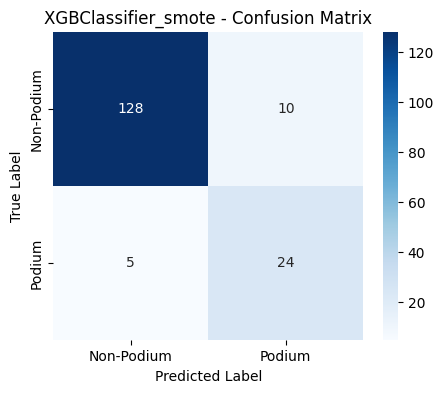

In [8]:
# fit all the models
%matplotlib inline

from imblearn.over_sampling import SMOTE

results = {}

for sampling_method in ['original', 'smote']:
    if sampling_method == 'smote':
        sm = SMOTE(random_state=42)
        X_res, y_res = sm.fit_resample(train_X, train_y)
    else:
        X_res, y_res = train_X, train_y

    print(f"\n=== Results using {sampling_method.upper()} data ===")

    for model in models:
        model.fit(X_res, y_res)
        pred_y = model.predict(test_X)
        test_prob = model.predict_proba(test_X)[:, 1]

        # store results
        key = f"{model.__class__.__name__}_{sampling_method}"
        results[key] = {"pred_y": pred_y, "true_y": test_y, "test_prob": test_prob}
        results_df = pd.DataFrame(results[key])

        # metrics
        accuracy = accuracy_score(test_y, pred_y)
        f1 = f1_score(test_y, pred_y)
        roc_auc = roc_auc_score(test_y, pred_y)
        cm = confusion_matrix(test_y, pred_y)

        print(f"{key}:")
        print(f"  Accuracy: {accuracy*100:.3f}%")
        print(f"  F1 Score: {f1:.3f}")
        print(f"  ROC AUC: {roc_auc:.2f}")
        print(results_df.head())

        # Confusion matrix
        labels = ['Non-Podium', 'Podium']
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels)
        plt.title(f"{key} - Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.show()

        # Shap
        # single_instance = X_res.iloc[[1]]
        # explainer = shap.Explainer(model, X_res)
        # shap_values = explainer(single_instance)
        # shap.plots.waterfall(shap_values[0], max_display=10)
    # ensures one chart per model


## Save Models

In [10]:
for model in models:
    model_name = model.__class__.__name__
    filename = f"Saved_Models/{model_name}.joblib"
    joblib.dump(model, filename)
    print(f"✅ Saved {model_name} to {filename}")

✅ Saved LogisticRegression to Saved_Models/LogisticRegression.joblib
✅ Saved DecisionTreeClassifier to Saved_Models/DecisionTreeClassifier.joblib
✅ Saved RandomForestClassifier to Saved_Models/RandomForestClassifier.joblib
✅ Saved GradientBoostingClassifier to Saved_Models/GradientBoostingClassifier.joblib
✅ Saved HistGradientBoostingClassifier to Saved_Models/HistGradientBoostingClassifier.joblib
✅ Saved XGBClassifier to Saved_Models/XGBClassifier.joblib
